In [4]:
import numpy as np
from Assignment2Tools import prob_vector_generator, markov_matrix_generator

def value_iteration(Swind, P, lmbda, B, eta, Delta, alpha, tau, gamma, beta, theta, Kmin):
    num_states = len(Swind)  # Number of wind speed states

    # Step 1: Initialize value function and policy
    V = np.zeros(num_states)  # Initialize V(s) = 0 for all states
    policy = np.zeros(num_states, dtype=int)  # Initialize policy (best action for each state)

    # Step 2: Iteratively update V(s) until convergence
    for _ in range(Kmin):
        V_new = np.copy(V)  # Create a copy of V to store updates

        # Loop over all states
        for s in range(num_states):
            best_value = -np.inf  # Start with a very low value
            best_action = None  # Store the best action

            # Loop over all possible actions (transmission values)
            for a in range(num_states):
                expected_value = 0

                # Loop over all possible next states
                for s_next in range(num_states):
                    R = - (Swind[s] - Swind[s_next])**2  # Reward function
                    P_sa = P[s, s_next]  # Transition probability

                    expected_value += P_sa * (R + beta * V[s_next])

                # Choose the best action
                if expected_value > best_value:
                    best_value = expected_value
                    best_action = a  # Store the best action

            # Update value function and policy
            V_new[s] = best_value
            policy[s] = best_action

        # Check for convergence
        if np.max(np.abs(V_new - V)) < theta:
            break  # Stop iteration if values have converged

        V = V_new  # Update value function

    return V, policy  # Return optimal value function and policy


# System parameters (set to default values)
Swind = np.linspace(0, 1, 21)                      # The set of all possible normalized wind speed.
mu_wind = 0.3                                      # Mean wind speed. You can vary this between 0.2 to 0.8.
z_wind = 0.5                                       # Z-factor of the wind speed. You can vary this between 0.25 to 0.75.
                                                   # Z-factor = Standard deviation divided by mean.
                                                   # Higher the Z-factor, the more is the fluctuation in wind speed.
stddev_wind = z_wind*np.sqrt(mu_wind*(1-mu_wind))  # Standard deviation of the wind speed.
retention_prob = 0.9                               # Retention probability is the probability that the wind speed in the current and the next time slot is the same.
                                                   # You can vary the retention probability between 0.05 to 0.95.
                                                   # Higher retention probability implies lower fluctuation in wind speed.
P = markov_matrix_generator(Swind, mu_wind, stddev_wind, retention_prob)  # Markovian probability matrix governing wind speed.

lmbda = 0.7  # Probability of successful transmission.

B = 10         # Maximum battery capacity.
eta = 2        # Battery power required for one transmission.
Delta = 3      # Maximum solar power in one time slot.
mu_delta = 2   # Mean of the solar power in one time slot.
z_delta = 0.5  # Z-factor of the slower power in one time slot. You can vary this between 0.25 to 0.75.
stddev_delta = z_delta*np.sqrt(Delta*(Delta-mu_delta))  # Standard deviation of the solar power in one time slot.
alpha = prob_vector_generator(np.arange(Delta+1), mu_delta, stddev_delta)  # Probability distribution of solar power in one time slot.

tau = 4       # Number of time slots in active phase.
gamma = 1/15  # Probability of getting chance to transmit. It can vary between 0.01 to 0.99.

beta = 0.95   # Discount factor.
theta = 0.01  # Convergence criteria: Maximum allowable change in value function to allow convergence.
Kmin = 10     # Convergence criteria: Minimum number of iterations to allow convergence.


# Call value iteration function and print results
V_optimal, policy_optimal = value_iteration(Swind, P, lmbda, B, eta, Delta, alpha, tau, gamma, beta, theta, Kmin)

print("Optimal Value Function:")
print(V_optimal)

print("\nOptimal Policy:")
print(policy_optimal)


Optimal Value Function:
[-0.1604902  -0.21224183 -0.11471519 -0.07654438 -0.06051096 -0.05294116
 -0.06493577 -0.06938084 -0.15355156 -0.08061179 -0.15294254 -0.10722861
 -0.21958919 -0.14588451 -0.16626984 -0.18416952 -0.22006507 -0.24793546
 -0.27486241 -0.32960114 -0.35099644]

Optimal Policy:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


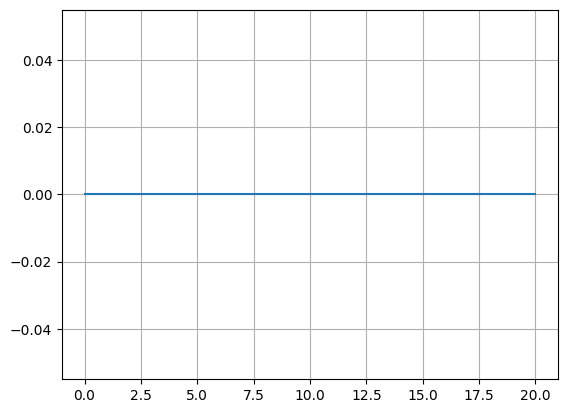

In [9]:
import matplotlib.pyplot as plt
plt.figure(1)
plt.plot(policy_optimal)
plt.grid()

In [10]:
import numpy as np
from Assignment2Tools import prob_vector_generator, markov_matrix_generator

def value_iteration(Swind, P, lmbda, B, eta, Delta, alpha, tau, gamma, beta, theta, Kmin):
    # Number of states
    num_states = len(Swind)

    # Initialize value function and policy
    V = np.zeros(num_states)
    policy = np.zeros(num_states, dtype=int)

    # Initialize iteration counter
    iteration = 0

    while True:
        V_prev = V.copy()  # Store previous value function for convergence check

        # Update value function for each state
        for s in range(num_states):
            # Calculate expected value for each action
            action_values = np.zeros(Delta + 1)  # Assuming actions are from 0 to Delta

            for action in range(Delta + 1):
                # Calculate expected value for this action
                expected_value = 0
                for next_state in range(num_states):
                    # Transition probability from state s to next_state
                    transition_prob = P[s, next_state]

                    # Reward calculation (negative squared error)
                    reward = -((Swind[next_state] - (Swind[s] if action == 0 else action)) ** 2) # no transaction implies action == 0 , use Swind[s]
                                                                                                 # no transmission implies action == 1, use Swind[next_state]
                    expected_value += transition_prob * (reward + gamma * V_prev[next_state])

                action_values[action] = expected_value

            # Update value function for state s
            V[s] = np.max(action_values)
            # Update policy for state s
            policy[s] = np.argmax(action_values)

        # Debugging output
        print(f"Iteration {iteration}:")
        print(f"Value Function: {V}")
        print(f"Action Values: {action_values}")
        print(f"Policy: {policy}")

        # Check for convergence
        if np.max(np.abs(V - V_prev)) < theta and iteration >= Kmin:
            break

        iteration += 1

    return V, policy

def main():
    # Different values for mu_wind, stddev_wind, and retention_prob
    mu_wind_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
    retention_prob_values = [0.05, 0.3, 0.5, 0.7, 0.9]

    for mu_wind in mu_wind_values:
        for retention_prob in retention_prob_values:
            print(f"\nRunning value iteration with mu_wind: {mu_wind}, retention_prob: {retention_prob}")

            # Set up parameters
            Swind = np.linspace(0, 1, 21)  # The set of all possible normalized wind speed.
            z_wind = 0.5  # Z-factor of the wind speed.
            stddev_wind = z_wind * np.sqrt(mu_wind * (1 - mu_wind))  # Standard deviation of the wind speed.

            # Generate Markovian probability matrix governing wind speed
            P = markov_matrix_generator(Swind, mu_wind, stddev_wind, retention_prob)

            lmbda = 0.7  # Probability of successful transmission.
            B = 10       # Maximum battery capacity.
            eta = 2      # Battery power required for one transmission.
            Delta = 3    # Maximum solar power in one time slot.
            mu_delta = 2  # Mean of the solar power in one time slot.
            z_delta = 0.5  # Z-factor of the solar power.
            stddev_delta = z_delta * np.sqrt(Delta * (Delta - mu_delta))  # Standard deviation of solar power.

            # Generate probability distribution of solar power
            alpha = prob_vector_generator(np.arange(Delta + 1), mu_delta, stddev_delta)

            tau = 4       # Number of time slots in active phase.
            gamma = 1/15  # Probability of getting chance to transmit.
            beta = 0.95   # Discount factor.
            theta = 0.01  # Convergence criteria.
            Kmin = 10     # Minimum number of iterations to allow convergence.

            # Call value iteration function
            V_optimal_vi, policy_optimal_vi = value_iteration(Swind, P, lmbda, B, eta, Delta, alpha, tau, gamma, beta, theta, Kmin)

            # Print the final results
            print("Final Optimal Value Function:")
            print(V_optimal_vi)
            print("Final Optimal Policy:")
            print(policy_optimal_vi)

if __name__ == "__main__":
    main()


Running value iteration with mu_wind: 0.2, retention_prob: 0.05
Iteration 0:
Value Function: [-0.10133271 -0.06670025 -0.04911797 -0.03938862 -0.036635   -0.0396607
 -0.04798469 -0.06137103 -0.07952342 -0.10232527 -0.12982165 -0.16195139
 -0.19870947 -0.24014946 -0.28626727 -0.33706277 -0.39259448 -0.45292774
 -0.51820625 -0.58814994 -0.66292152]
Action Values: [-0.66292152 -0.66292152 -3.21201674 -7.76111197]
Policy: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Iteration 1:
Value Function: [-0.10711683 -0.07241831 -0.0547744  -0.04489551 -0.04201143 -0.0449314
 -0.05318239 -0.06653722 -0.08469212 -0.10752068 -0.13507995 -0.16729792
 -0.20417039 -0.24574643 -0.2920256  -0.34300435 -0.39873871 -0.45928675
 -0.5247849  -0.59496701 -0.6699917 ]
Action Values: [-0.6699917  -0.6699917  -3.21908692 -7.76818215]
Policy: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Iteration 2:
Value Function: [-0.1074854  -0.07278734 -0.05514418 -0.04526574 -0.04238167 -0.04530137
 -0.05355198 -0.06690645 -0.0

In [13]:
import numpy as np
from Assignment2Tools import prob_vector_generator, markov_matrix_generator

def value_iteration(Swind, P, lmbda, B, eta, Delta, alpha, tau, gamma, beta, theta, Kmin):
    num_states = len(Swind)
    num_battery_levels = B + 1

    # V[wind_state][battery_level]
    V = np.zeros((num_states, num_battery_levels))
    policy = np.zeros((num_states, num_battery_levels), dtype=int)

    iteration = 0
    while True:
        V_prev = V.copy()

        for wind_idx in range(num_states):
            for battery in range(num_battery_levels):
                action_values = np.full(Delta + 1, -np.inf)

                for action in range(Delta + 1):
                    if battery < eta * action:
                        continue  # Not enough battery to take this action

                    expected_value = 0
                    for next_wind_idx in range(num_states):
                        prob = P[wind_idx, next_wind_idx]
                        reward = -((Swind[next_wind_idx] - (Swind[wind_idx] if action == 0 else action)) ** 2)

                        # New battery level after solar recharge
                        battery_after_tx = battery - eta * action
                        solar_value = 0
                        for solar, prob_solar in enumerate(alpha):
                            new_battery = min(battery_after_tx + solar, B)
                            solar_value += prob_solar * V_prev[next_wind_idx, new_battery]

                        expected_value += prob * (reward + beta * solar_value)

                    action_values[action] = expected_value

                best_action = np.argmax(action_values)
                V[wind_idx, battery] = action_values[best_action]
                policy[wind_idx, battery] = best_action

        if np.max(np.abs(V - V_prev)) < theta and iteration >= Kmin:
            break

        iteration += 1
        print(f"Iteration {iteration} done.")

    return V, policy

def main():
    # Different values for mu_wind, stddev_wind, and retention_prob
    mu_wind_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
    retention_prob_values = [0.05, 0.3, 0.5, 0.7, 0.9]

    for mu_wind in mu_wind_values:
        for retention_prob in retention_prob_values:
            print(f"\nRunning value iteration with mu_wind: {mu_wind}, retention_prob: {retention_prob}")

            # Set up parameters
            Swind = np.linspace(0, 1, 21)  # The set of all possible normalized wind speed.
            z_wind = 0.5  # Z-factor of the wind speed.
            stddev_wind = z_wind * np.sqrt(mu_wind * (1 - mu_wind))  # Standard deviation of the wind speed.

            # Generate Markovian probability matrix governing wind speed
            P = markov_matrix_generator(Swind, mu_wind, stddev_wind, retention_prob)

            lmbda = 0.7  # Probability of successful transmission.
            B = 10       # Maximum battery capacity.
            eta = 2      # Battery power required for one transmission.
            Delta = 3    # Maximum solar power in one time slot.
            mu_delta = 2  # Mean of the solar power in one time slot.
            z_delta = 0.5  # Z-factor of the solar power.
            stddev_delta = z_delta * np.sqrt(Delta * (Delta - mu_delta))  # Standard deviation of solar power.

            # Generate probability distribution of solar power
            alpha = prob_vector_generator(np.arange(Delta + 1), mu_delta, stddev_delta)

            tau = 4       # Number of time slots in active phase.
            gamma = 1/15  # Probability of getting chance to transmit.
            beta = 0.95   # Discount factor.
            theta = 0.01  # Convergence criteria.
            Kmin = 10     # Minimum number of iterations to allow convergence.

            # Call value iteration function
            V_optimal_vi, policy_optimal_vi = value_iteration(Swind, P, lmbda, B, eta, Delta, alpha, tau, gamma, beta, theta, Kmin)

            # Print the final results
            print("Final Optimal Value Function:")
            print(V_optimal_vi)
            print("Final Optimal Policy:")
            print(policy_optimal_vi)

if __name__ == "__main__":
    main()


Running value iteration with mu_wind: 0.2, retention_prob: 0.05
Iteration 1 done.
Iteration 2 done.
Iteration 3 done.
Iteration 4 done.
Iteration 5 done.
Iteration 6 done.
Iteration 7 done.
Iteration 8 done.
Iteration 9 done.
Iteration 10 done.
Iteration 11 done.
Iteration 12 done.
Iteration 13 done.
Iteration 14 done.
Iteration 15 done.
Iteration 16 done.
Iteration 17 done.
Iteration 18 done.
Iteration 19 done.
Iteration 20 done.
Iteration 21 done.
Iteration 22 done.
Iteration 23 done.
Iteration 24 done.
Iteration 25 done.
Iteration 26 done.
Iteration 27 done.
Iteration 28 done.
Iteration 29 done.
Iteration 30 done.
Iteration 31 done.
Iteration 32 done.
Iteration 33 done.
Iteration 34 done.
Iteration 35 done.
Iteration 36 done.
Iteration 37 done.
Iteration 38 done.
Iteration 39 done.
Iteration 40 done.
Iteration 41 done.
Iteration 42 done.
Final Optimal Value Function:
[[-1.50077304 -1.50077304 -1.50077304 -1.50077304 -1.50077304 -1.50077304
  -1.50077304 -1.50077304 -1.50077304 -1.5